In [ ]:
import os
import zipfile
from pathlib import Path
BASE_DIR = os.getcwd()

with zipfile.ZipFile(os.path.join(BASE_DIR, 'data', '2B.zip'), 'r') as zip_ref:
    zip_ref.extractall(os.path.join(BASE_DIR, 'data')) #local run

Definisikan direktori yang akan dipakai

In [2]:
CHERRY_PATH = Path(os.path.join(BASE_DIR, 'data', '2C', 'Cherry', 'data'))
image_paths = list(CHERRY_PATH.glob(r'**/*.jpg'))

Import Library

In [16]:
from PIL import Image
import pandas as pd
import shutil
import random

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()
    print(f"Seed ditetapkan ke: {seed}")
set_seed(42)




Seed ditetapkan ke: 42


In [7]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU not found')
else:
    print(f'GPU ditemukan di: {device_name}')

GPU not found


#### **A. Explarotary Data Analysis**

untuk memeriksa kondisi data yang anda miliki, seperti
aspect ratio & resolution. Lalu pisahkan data anda menjadi
train, validation, dan test dengan proporsi 70:15:15!

Baca dan identifikasi informasi metadata image seperti lebar, tinggi, aspect ratio lalu catat ke dataframe untuk dianalisa

In [9]:
dims = []
for img_path in image_paths:
    with Image.open(img_path) as img:
        width, height = img.size
        aspect_ratio = width / height
        dims.append((width, height, aspect_ratio))

data = []
for img_path in image_paths:
    class_name = img_path.parent.name
    data.append((class_name, 1))

df_data = pd.DataFrame(data, columns=["Class", "Count"])
df_dims = pd.DataFrame(dims, columns=['Width', 'Height', 'Aspect_Ratio'])

In [10]:
df = pd.concat([df_data, df_dims], axis=1)

In [11]:
df.head(5)

,Class,Count,Width,Height,Aspect_Ratio
0,Cherry brown_spot,1,800,1000,0.8
1,Cherry brown_spot,1,800,1000,0.8
2,Cherry brown_spot,1,800,1000,0.8
3,Cherry brown_spot,1,800,1000,0.8
4,Cherry brown_spot,1,800,1000,0.8


Ringkasan statistik per kelas

In [12]:
display(df.groupby('Class').agg({'Width':['mean', 'std'], 'Height':['mean', 'std'], 'Aspect_Ratio':'mean'}))

Width       Height      Aspect_Ratio
                           mean  std    mean  std         mean
Class                                                         
Cherry Leaf Scorch        800.0  0.0  1000.0  0.0          0.8
Cherry Normal leaf        800.0  0.0  1000.0  0.0          0.8
Cherry brown_spot         800.0  0.0  1000.0  0.0          0.8
Cherry purple leaf spot   800.0  0.0  1000.0  0.0          0.8
Cherry_shot hole disease  800.0  0.0  1000.0  0.0          0.8

#### **Data Splitting (70:15:15)**

Berikut adalah proses pembagian data ke dalam folder `train`, `val`, dan `test` dengan proporsi yang ditentukan.

SPLIT_OUTPUT_DIR untuk output splitting dataset

Bagi dari 70% Train + 30% (val & test) lalu split lagi val dan test dengan size 0.5

Pindahkan image ke folder pemisahan masing-masing

In [13]:
classes = os.listdir(CHERRY_PATH)
SPLIT_OUTPUT_DIR = os.path.join(BASE_DIR, 'split_dataset')
if os.path.exists(SPLIT_OUTPUT_DIR): shutil.rmtree(SPLIT_OUTPUT_DIR)

for cls in classes:
    cls_path = os.path.join(CHERRY_PATH, cls)
    images = [os.path.join(cls_path, img) for img in os.listdir(cls_path) if img.endswith('.jpg')]

    train_files, temp_files = train_test_split(images, test_size=0.30, random_state=42)

    val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=42)

    def move_to_folder(files, split_name):
        dest_dir = os.path.join(SPLIT_OUTPUT_DIR, split_name, cls)
        os.makedirs(dest_dir, exist_ok=True)
        for f in files:
            shutil.copy(f, os.path.join(dest_dir, os.path.basename(f)))

    move_to_folder(train_files, 'train')
    move_to_folder(val_files, 'val')
    move_to_folder(test_files, 'test')

print(f"Data berhasil dipisah di: {SPLIT_OUTPUT_DIR}")

Data berhasil dipisah di: c:\Users\Alvin\Music\Git Project\2802393062 - Alvin Wijaya\split_dataset


Masukan direktori `train` `val` dan `test` dan catat untuk diakses oleh modelling nanti

In [14]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(SPLIT_OUTPUT_DIR, 'train'),
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(SPLIT_OUTPUT_DIR, 'val'),
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(SPLIT_OUTPUT_DIR, 'test'),
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32
)

#optimize GPU Colab
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2333 files belonging to 5 classes.
Found 501 files belonging to 5 classes.
Found 504 files belonging to 5 classes.


Contoh sampel

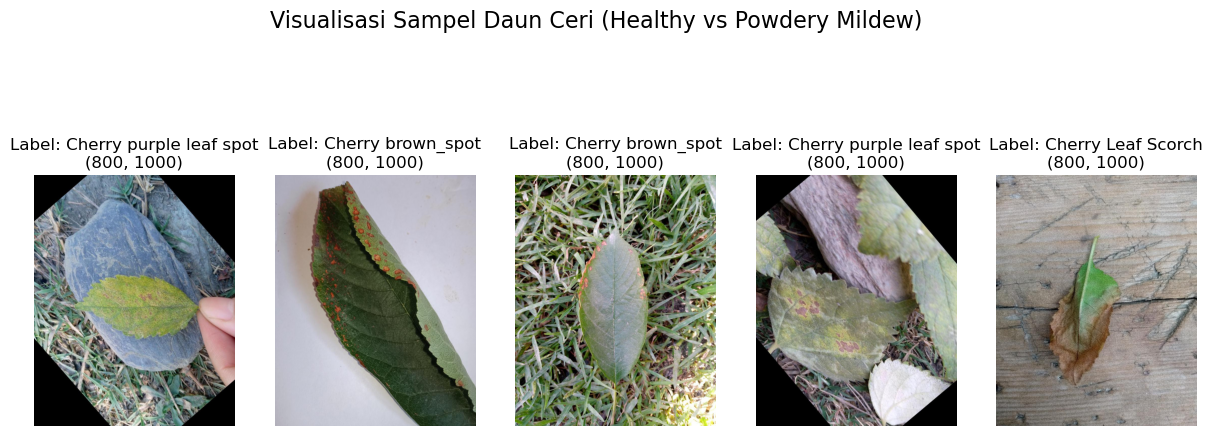

In [15]:
def plot_samples(image_paths, n=5):
    plt.figure(figsize=(15, 6))
    
    samples = random.sample(image_paths, n)

    for i, img_path in enumerate(samples):
        plt.subplot(1, n, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        
        plt.title(f"Label: {img_path.parent.name}\n{img.size}")
        plt.axis('off')
    plt.suptitle("Visualisasi Sampel Daun Ceri (Healthy vs Powdery Mildew)", fontsize=16)
    plt.show()

plot_samples(image_paths)

/tmp/ipykernel_9721/1692120630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='viridis')


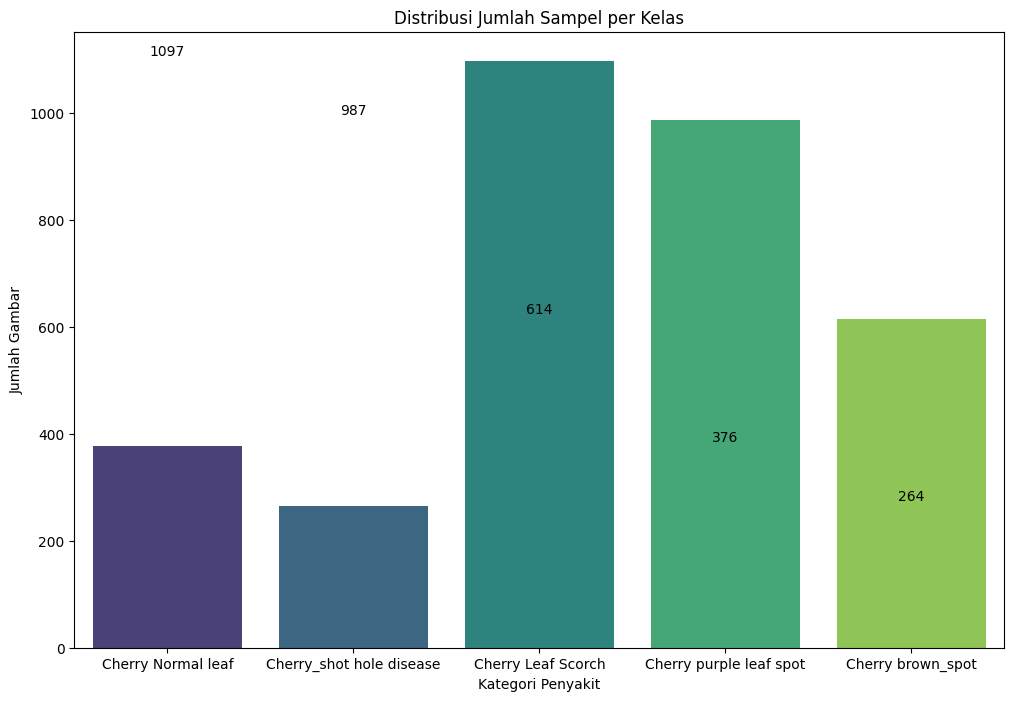

In [14]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Class', palette='viridis')
plt.title('Distribusi Jumlah Sampel per Kelas')
plt.xlabel('Kategori Penyakit')
plt.ylabel('Jumlah Gambar')

# Menambahkan label angka di atas bar
counts = df['Class'].value_counts()
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom')

plt.show()

Distribusi nilai pixel secara random, set seed berada di 42

--- Analisis Intensitas Pixel ---
Bentuk Array Gambar: (1000, 800, 3)
Nilai Pixel Maksimum: 255
Nilai Pixel Minimum: 0
Nilai Rata-rata Pixel: 123.47


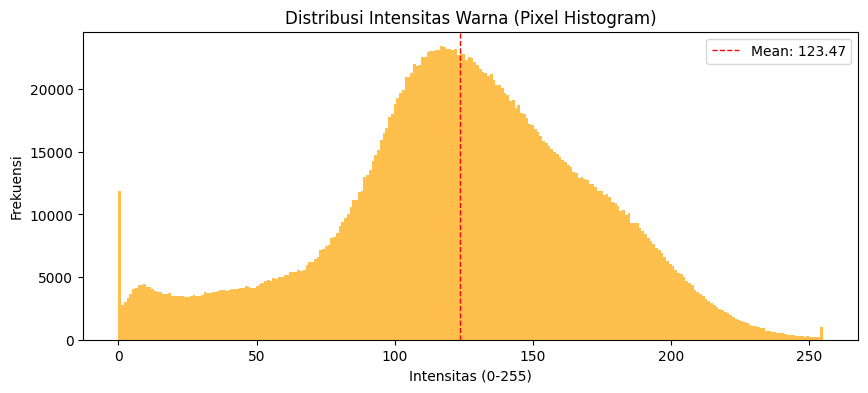

In [ ]:
sample_img_path = image_paths[0]
sample_img = np.array(Image.open(sample_img_path))

print(f"--- Analisis Intensitas Pixel ---")
print(f"Bentuk Array Gambar: {sample_img.shape}")
print(f"Nilai Pixel Maksimum: {sample_img.max()}")
print(f"Nilai Pixel Minimum: {sample_img.min()}")
print(f"Nilai Rata-rata Pixel: {sample_img.mean():.2f}")

plt.figure(figsize=(10, 4))
plt.hist(sample_img.ravel(), bins=256, color='orange', alpha=0.7)
plt.title("Distribusi Intensitas Warna (Pixel Histogram)")
plt.xlabel("Intensitas (0-255)")
plt.ylabel("Frekuensi")
plt.axvline(sample_img.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {sample_img.mean():.2f}')
plt.legend()
plt.show()

Fungsi Plotting Model CNN

In [16]:
def plot_training_results(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.show()

### **B.  Buatlah sebuah model CNN AlexNet**


In [ ]:
def build_baseline_alexnet(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=input_shape),

        layers.Conv2D(96, (11, 11), strides=4, padding='valid', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=2),

        layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=2),

        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=2),

        layers.Flatten(),

        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Model Baselinex AlexNet: replikasi dari arsitektur standard oleh Krizhevsky dkk. Model ini menjadi fondasi sebelum dilakukan modifikasi.

1. Penyesuain input layer. AlexNet asli dirancang untuk input 227 x 227. Penggunaan 224 x 224 menjadi standar modern mengikuti arsitektur CNN populer.

2. Rescaling (1./255) dilakukan untuk memastikan stabilitas gradien saat proses back propagation melalui normalisasi.

3. Memiliki 5 layer konvolusi diikuti oleh 3 lapisan fully-connected utk ekstraksi fitur dari yang paling sederhana (tepi dan warna) hingga fitur kompleks seperti bercak penyakit pada daun.

4. Kernel besar di awal dengan filter 11 x 11 pada lapisan pertama untuk menangkap informasi spasial yang luas dari citra daun ceri. Max Pooling lalu ditaruh setelah dimension reduction untuk menjaga fitur tetap dominan dan efisien.

5. Relu Activation agar mengatasi vanishing gradient dan memungkinkan pelatihan jaringan yang lebih dalam dan cepat.

6. Overfitting Control menggunakan Dropout pada bagian fully connected untuk mengurangi ketergantungan pada neuron untuk meningkatkan kemampuan generalisasi


In [ ]:
baseline_model = build_baseline_alexnet()

baseline_model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Training Baseline Model

In [19]:
EPOCHS = 10

history_baseline = baseline_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = EPOCHS
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - accuracy: 0.3862 - loss: 0.4632 - val_accuracy: 0.5589 - val_loss: 0.3719
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.6031 - loss: 0.3424 - val_accuracy: 0.7106 - val_loss: 0.2645
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.7557 - loss: 0.2351 - val_accuracy: 0.7984 - val_loss: 0.1860
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.8153 - loss: 0.1848 - val_accuracy: 0.8363 - val_loss: 0.1710
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8504 - loss: 0.1479 - val_accuracy: 0.8703 - val_loss: 0.1336
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.8761 - loss: 0.1306 - val_accuracy: 0.8583 - val_loss: 0.1343
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.8813 - loss: 0.1196 - val_accuracy: 0.8663 - val_loss: 0.1275
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8881 - loss: 0.1150 - val_accuracy: 0.8882 - 

Plotting Baseline Model

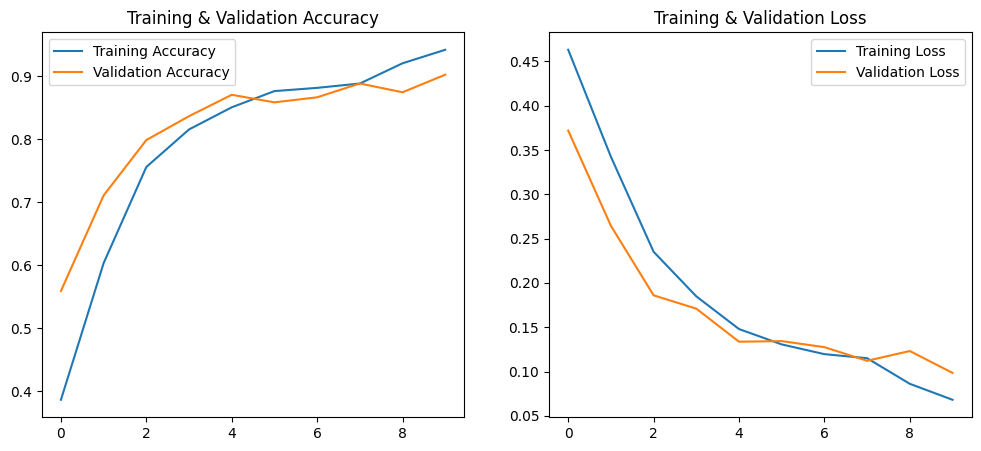

In [20]:
plot_training_results(history_baseline)

Baseline model mencapai akurasi training sekitar 93-94% dan akurasi validasi di kisaran 88-89%. Nilai loss training (biru) menurun secara konsisten menuju titik optimal, yang menandakan gradien model stabil.

Sedangkan nilai kurva validation memiliki gejolak kenaikan pada epoch 4 dan mulai stabil di 0.1 ~ 0.15 lossnya.

Model baseline cenderung melakukan konvergensi dengan baik meski terdeteksi overfitting ringan dimana akurasi training dan loss training menunjukan model lebih pintar menghafal data.

### **C.1. Modifikasi Arsitektur AlexNet**

yang sudah dibuat. Anda bisa menambahkan DropOut, Batch Normalization, dan sebagainya atau melakukan fine-tuning untuk hyperparameter pada model ini. Anda juga bisa mengganti modelnya dengan arsitektur CNN lain seperti DenseNet, EfficientNet, dan sebagainya. Jelaskan alasan modifikasi anda dan lakukan training (minimal 10 epoch), serta analisis hasilnya.


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,         
    patience=4,         
    min_lr=0.000001,    
    verbose=1           
)

early_stop = EarlyStopping(
    monitor='val_loss',   
    patience=10,           
    restore_best_weights=True, 
    verbose=1
)

In [ ]:
def build_alexnet_tuned(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(224, 224, 3)),

        layers.Conv2D(96, (11, 11), strides=4, padding='valid', activation='relu',
                      input_shape=input_shape, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((3, 3), strides=2),


        layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=2),
        layers.BatchNormalization(),

        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=2),

        layers.GlobalAveragePooling2D(),

        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(5, activation='softmax')
    ])

    return model

Modifikasi yang dilakukan:

1. Menambahkan BatchNormalization membantu menstabilkan proses training dan mempercepat konvergensi dibanding AlexNet Asli yang menggunakan Local Response Normalization.
2. Penyesuaian lapisan pada Dense dari softmax

Pada proses training:
1. Increase dari 10 ke 35 epoch maximum
2. Gunakan LR-Optimizer saat stagnan dan EarlyStopping jika model berhenti belajar
3. Learning Rate menjadi 0.0001


In [94]:
tuned_model = build_alexnet_tuned()
tuned_model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

tuned_model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_18 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,603,077 (82.41 MB)

 Trainable params: 21,602,373 (82.41 MB)

 Non-trainable params: 704 (2.75 KB)

In [95]:
EPOCHS = 35

history_tuned = tuned_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = EPOCHS,
    callbacks = [lr_scheduler, early_stop]
)

Epoch 1/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6447 - loss: 0.3050 - val_accuracy: 0.3293 - val_loss: 0.5188 - learning_rate: 1.0000e-04
Epoch 2/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.8611 - loss: 0.1403 - val_accuracy: 0.3493 - val_loss: 0.5135 - learning_rate: 1.0000e-04
Epoch 3/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8993 - loss: 0.1001 - val_accuracy: 0.4511 - val_loss: 0.5641 - learning_rate: 1.0000e-04
Epoch 4/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9352 - loss: 0.0675
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9331 - loss: 0.0694 - val_accuracy: 0.6088 - val_loss: 0.4315 - learning_rate: 1.0000e-04
Epoch 5/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9593 - loss: 0.0429 - val_accuracy: 0.6986 - val_loss: 0.4413 - learning_rate: 2.0000e-05
Epoch 6/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9751 - lo

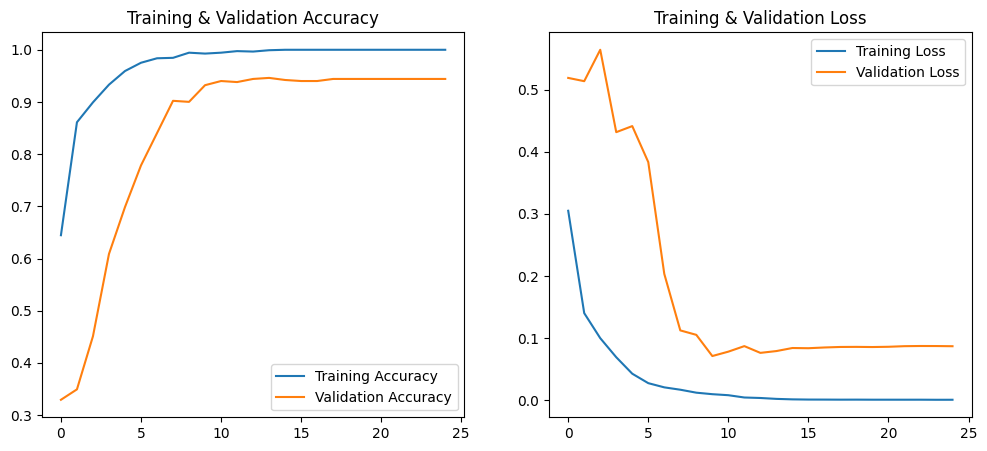

In [96]:
plot_training_results(history_tuned)

Hasil Modified AlexNet:
1. Stabilitas lebih tinggi, berbeda pada baseline, pergerakan menjadi lebih stabil pada akurasi validasi yang membuktikan batch normalization sebelum aktivasi sukses membuat gradient lebih smooth
2. Titik konvergensi untuk validasi ditemukan di epoch 8
3. Gap minimal berada sangat dekat antara training dan validasi membuat model memiliki kemampuan generalisasi yang baik

### **C.2 Modifikasi CNN ResNet50**

Terlihatnya gejolaknya validation loss pada alexnet mengindikasikan perlunya pendekatan baru untuk achieve model yang lebih stabil

Kita akan menggunakan model Pre-Trained ResNet50 yang sangat populer.

In [104]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

def build_modified_model(input_shape=(224, 224, 3)):
    base_model = ResNet50(input_shape=input_shape,
                          include_top=False,
                          weights='imagenet')

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

modified_model = build_modified_model()
modified_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_18     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,733 (92.02 MB)

 Trainable params: 529,925 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Modifikasi pada model ResNet:
1. menggunakan GlobalAveragePooling
2. Batch Normalisasi sebelum aktivasi
3. lalu dropout di 0.4
4. dan dense dengan aktivasi softmax

In [107]:
history_modified = modified_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - accuracy: 0.6905 - loss: 0.8625 - val_accuracy: 0.9022 - val_loss: 0.3901 - learning_rate: 1.0000e-04
Epoch 2/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.9053 - loss: 0.2739 - val_accuracy: 0.9321 - val_loss: 0.2377 - learning_rate: 1.0000e-04
Epoch 3/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.9494 - loss: 0.1603 - val_accuracy: 0.9361 - val_loss: 0.1742 - learning_rate: 1.0000e-04
Epoch 4/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9645 - loss: 0.1179
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.9610 - loss: 0.1220 - val_accuracy: 0.9501 - val_loss: 0.1485 - learning_rate: 1.0000e-04
Epoch 5/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.9786 - loss: 0.0838 - val_accuracy: 0.9541 - val_loss: 0.1382 - learning_rate: 2.0000e-05
Epoch 6/35
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - accuracy

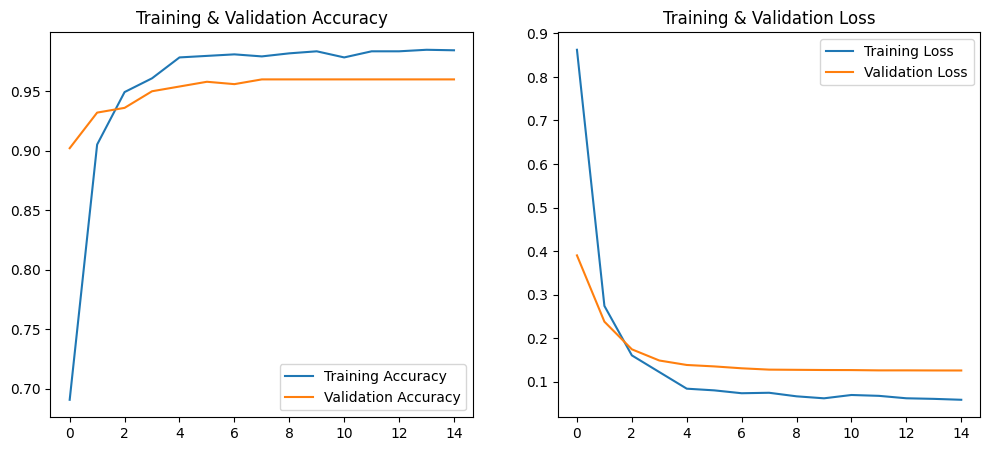

In [108]:
plot_training_results(history_modified)

Terlihat dari gambar training vs validasi:
1. ResNet memiliki Akurasi instan bahwa pada 4 epoch pertama yang membuktikan bahwa fitur-fitur dasar (garis, tekstur, warna) yang dipelajari ResNet dari ImageNet sangat relevan untuk deteksi penyakit daun ceri
2. Stability Loss menurun sangat tajam dan konsisten pada training dan juga validation yang bekerja sangat harmonis dengan ResNet
3. Sangat dekatnya hasil akurasi dan loss dari training dan validasi mengindikasikan kemampuan model yang sangat baik dalam generalisasi dan tidak overfit.

Compare Model

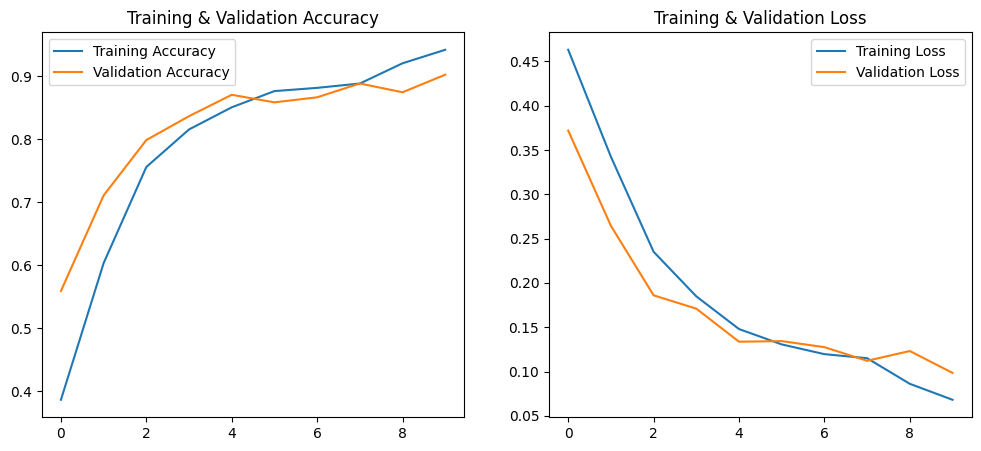

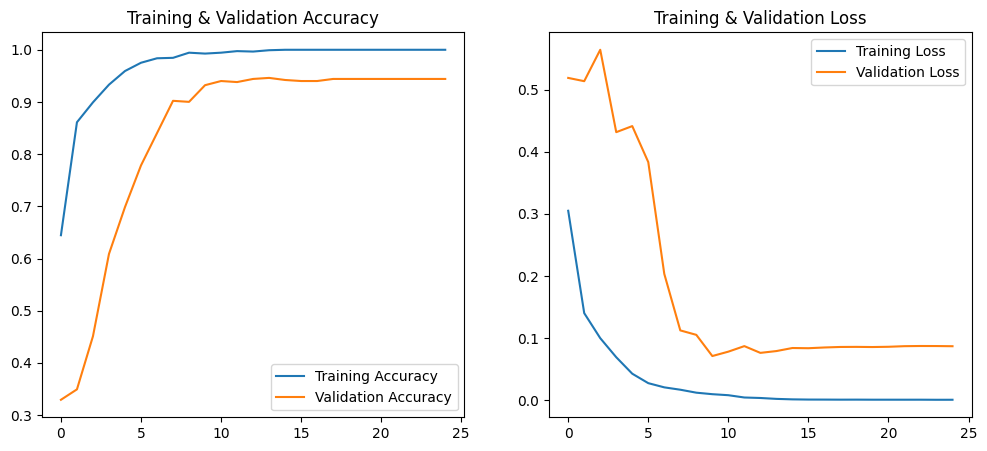

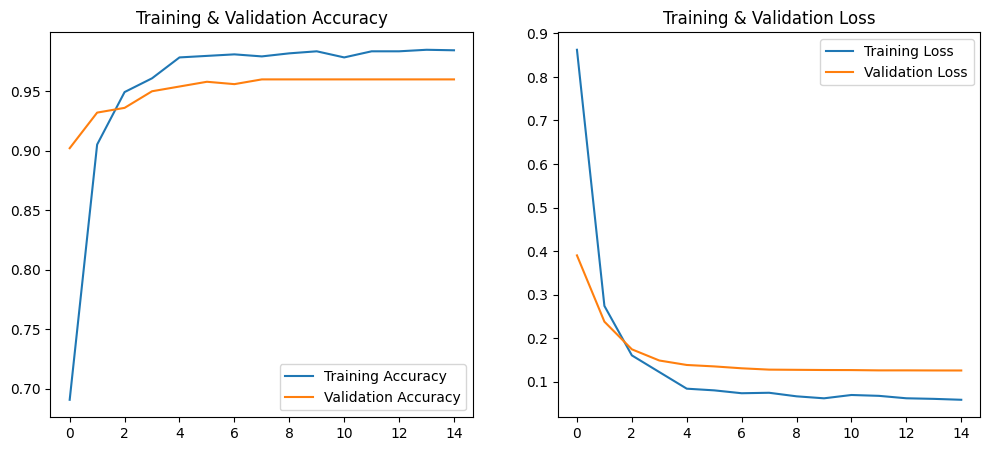

In [109]:
plot_training_results(history_baseline)
plot_training_results(history_tuned)
plot_training_results(history_modified)

In [101]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
import numpy as np

class_names = ['Cherry Leaf Scorch', 'Cherry Normal leaf', 'Cherry brown_spot',
               'Cherry purple leaf spot', 'Cherry_shot hole disease']

def evaluate_model(models):
  test_loss, test_acc = models.evaluate(test_ds)

  y_true = []
  y_pred = []

  for images, labels in test_ds:
      preds = models.predict(images)
      y_true.extend(np.argmax(labels, axis=1))
      y_pred.extend(np.argmax(preds, axis=1))

  print(f"Final Test Accuracy: {test_acc*100:.2f}%")
  print("\nClassification Report:")
  print(f"{classification_report(y_true, y_pred, target_names=class_names)}")
  print(f"Recall: {recall_score(y_true, y_pred, average = 'weighted')}")
  print(f"Precision: {precision_score(y_true, y_pred, average = 'weighted')}")
  print(f"F1_weighted: {f1_score(y_true, y_pred, average='weighted')}")

In [105]:
evaluate_model(baseline_model)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8929 - loss: 0.1113
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Final Test Accuracy: 89.29%

Classification Report:
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.97      0.95      0.96       165
      Cherry Normal leaf       0.62      0.84      0.72        57
       Cherry brown_spot       0.95      0.75      0.84        93
 

In [110]:
evaluate_model(modified_model)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.8929 - loss: 0.3892
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Final Test Accuracy: 89.29%

Classification Report:
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.93      0.92      0.92       165
      Cherry Normal leaf       0.76      0.77      0.77        57
       Cherry brown_spot       0.82      0.85     

Summary:
1. Kedua model memiliki hasil evaluasi yang cukup identik.
2. Keunggulan Baseline (AlexNet) dimana pada kelas Cherry Leaf Scorch (f1-score 0.96) dan cherry purple leaf spot (f1-score 0.97) menunjukan model memiliki presisi dan recall yang baik dan jarang memberikan alarm palsu
3. Keunggulan ResNet menunjukan performa yang lebih rata pada kelas sulit misalnya Cherry Normal Leaf (f1-score 0.77) sedangkan baseline memiliki (f1-score 0.72). Pada deteksi shot hole disease ResNet50 memiliki presisi yang sangat tinggi dan hampir tidak pernah salah klasifikasi daun lain sebagai shot hole.

Saran:
Gunakan ResNet 50 untuk pengembangan jangka panjang akibat volatilitasnya yang lebih rendah pada plotting training vs validasi